In [1]:
import csv
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import statistics
import time

import importlib
import TeloPeakCounter
from TeloPeakCounter import isGStrand, graphPeaks, getTeloCountLength
# from multiprocessing import Pool
# !pip install pandarallel

from pandarallel import pandarallel

importlib.reload(TeloPeakCounter)


<module 'TeloPeakCounter' from 'c:\\Users\\Ramin Kahidi\\Documents\\GitHub\\TeloPeakCounter\\TeloPeakCounter.py'>

In [2]:
# The following command is used to shuffle reads then grab the first 1000 reads, as the first reads will be shorter than those read later on 
# shuf -n 1000 .\SquigglePull.data.all.tsv > .\SquigglePull.data.1000SubSample.tsv

file_path = './Data/Fast5/SquigglePull.nanopore.data.tsv/SquigglePull.data.1000SubSample.tsv'

print("Start table")
# This table holds information about the reads, specifically the strand type (G or C) which will be used to determine the telomere count
readInfoDf = pd.read_csv("./Data/Guppy.dorado.reads.information.table.tsv", sep="\t")
print("Finished reading readInfoDf")

Start table
Finished reading readInfoDf


In [3]:
# Old code to read in data
# reducedDataDf = pd.read_csv(file_path, sep='\t', compression="gzip", error_bad_lines=False)
# reducedDataDf = reducedDataDf.head(50)
# reducedDataDf["signal"] = reducedDataDf["signal"].apply(lambda x: [float(i) for i in ast.literal_eval(x)])
# signalDf = reducedDataDf

rawReadsInList = []
with open(file_path, 'r', newline='') as tsv_file:
    chunk = csv.reader(tsv_file, delimiter='\t')

    # for each row in chunk, convert signal column from string to list of floats
    for row in chunk:
        qnm = row[1]
        print(qnm)
        signal = row[2:]

        # remove nan and non numerics
        signal = [float(x) for x in signal if isinstance(x, (int, float)) or (isinstance(x, str) and x != 'nan' and not x.endswith('.fast5') and "-" not in x)]
        # signal = [x for x in signal if str(x) != 'nan']
        # signal = [float(i) for i in signal]
        rawReadsInList.append([qnm, signal])
    print(len(rawReadsInList))
    # close file
    tsv_file.close()

print("done loading")

print(f"Length of rawReadsInList: {len(rawReadsInList)}")
signalDf = pd.DataFrame(rawReadsInList, columns=["qname", "signal"])

cb9057a0-e0d3-4b55-b8a2-e0e62eae4f75
1af86b00-646f-4b61-a836-bbb7dc658298
5eaf6bf6-6540-4539-bca5-08b297ff2b06
08dce1e1-4df8-4210-958b-fe27b35b95f2
36cd33a0-7809-44d8-947f-9726455b1b31
5e9b6c39-02ac-4c85-9b65-15cf1e902b6c
d6519078-4811-469c-a349-f1db9950894b
7e6e38c4-c05a-44b1-85d1-a4022c6f2cba
f8d43864-aee1-4e5b-a8d8-a0a1f47b5cd4
d7b9fd68-7c37-45e0-83fb-7e8c265a5a02
d9ca1cf5-b707-4e12-9345-72de29542b2a
984ef59c-46d3-44dc-99bb-12987470dbce
56ef426b-2e7b-44d8-bb27-708062990cd9
356848dc-1446-4301-943b-33bc38f3e7cd
26eedefb-fe2b-4ea7-9ffa-75f2ce611a95
3b01ab86-6b06-47c9-ab50-706b7e92c686
9f906f7b-4235-4874-8f82-86a4318d819f
eb3190d5-873a-4f8e-a8f7-8d8f760349fb
6b79e719-abe0-41dd-b7b6-5230c2ed0299
73a21db6-2478-4f69-8741-b377ec9f9957
f99fbbfc-1abe-4b75-bf61-19cb4597c1e4
0d7c5d6e-cdbc-40d9-81ab-515b6067a837
508cd784-88c5-4f80-a86f-ab1164345d63
0eb49e73-3576-4f52-9a7d-c25cca8926da
440affe1-e51f-4e7e-a60d-51e1026b09e8
f75f807a-e41a-4761-af3c-b221bf299d91
cb2fc9c6-f536-48a7-a753-cbc5403a8ca9
5

In [ ]:

readInfoWithSignal = readInfoDf[readInfoDf["qname"].isin(signalDf["qname"])]

readInfoWithSignal["isGStrand"] = readInfoWithSignal.apply(lambda row: isGStrand(row["chr"][-1] ,row["strand"]),axis=1)
signalDf = signalDf.merge(readInfoWithSignal[['qname', 'isGStrand', 'TeloBP.dorado.length', 'TeloNP.guppy.length','seq.ln.dorado', 'seq.ln.guppy', 'Telomere.adap']], on='qname', how='left')

print(signalDf.head())


                                  qname  \
0  cb9057a0-e0d3-4b55-b8a2-e0e62eae4f75   
1  cb9057a0-e0d3-4b55-b8a2-e0e62eae4f75   
2  cb9057a0-e0d3-4b55-b8a2-e0e62eae4f75   
3  1af86b00-646f-4b61-a836-bbb7dc658298   
4  1af86b00-646f-4b61-a836-bbb7dc658298   

                                              signal isGStrand  \
0  [777.0, 433.0, 442.0, 443.0, 563.0, 640.0, 532...      True   
1  [777.0, 433.0, 442.0, 443.0, 563.0, 640.0, 532...      True   
2  [777.0, 433.0, 442.0, 443.0, 563.0, 640.0, 532...      True   
3  [527.0, 540.0, 517.0, 517.0, 533.0, 538.0, 536...      True   
4  [527.0, 540.0, 517.0, 517.0, 533.0, 538.0, 536...      True   

   TeloBP.dorado.length  TeloNP.guppy.length  seq.ln.dorado  seq.ln.guppy  \
0                5321.0               4766.0        30785.0       30785.0   
1                5321.0               4766.0        30785.0       30785.0   
2                5321.0               4766.0        30785.0       30785.0   
3                3941.0             

C:\Users\Ramin Kahidi\AppData\Local\Temp\ipykernel_61688\120988890.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  readInfoWithSignal["isGStrand"] = readInfoWithSignal.apply(lambda row: isGStrand(row["chr"][-1] ,row["strand"]),axis=1)


In [ ]:
# check for duplicate qnames
print(f"Number of duplicates: {signalDf.duplicated(subset=['qname']).sum()}")


In [ ]:
# signalDf["PeakCountBasedLength"] = signalDf.apply(getTeloCountLength,axis=1)

pandarallel.initialize(progress_bar=True )
# The reason this is named peak count "guppy strand info" is because the strand type (c vs g strand) is based on the alignments made with guppy. 
# This should not make a meaningful difference compared to strand info calculated with the dorado base caller, but it is worth noting.
signalDf["PeakCountBasedLengthGuppyStrandInfo"] = signalDf.parallel_apply(getTeloCountLength,axis=1)

# drop signal column
saveDf = signalDf.drop(columns=["signal"])

readInfoWithSignalShortened = signalDf
saveDf.to_csv('output/subset1000.peak.count.tsv', sep='\t')
print("Finished processing")

In [5]:
graphingDF = pd.read_csv('output/F63.subset1000.peak.count.tsv', sep='\t')
graphingDF

In [45]:
from matplotlib.backends.backend_pdf import PdfPages
# pp = PdfPages("./Figures/AllFigures.pdf")

pearson correlation: 0.9103550064637206
R squared: 0.8287462377935607
2435
2435


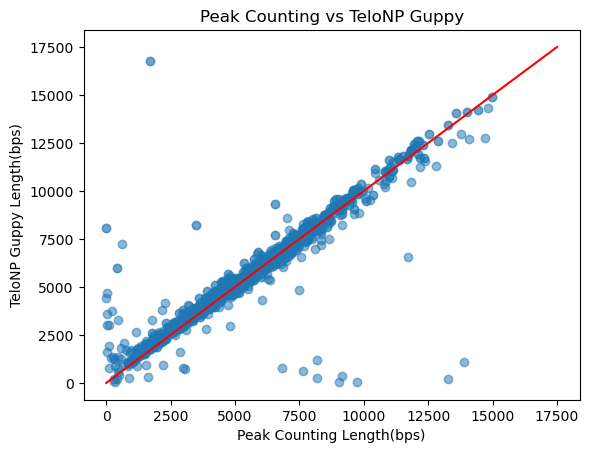

GStrand pearson correlation: 0.9930823795277507
GStrand R squared: 0.9862126125284995
CStrand pearson correlation: 0.9207378564063342
CStrand R squared: 0.8477582002197314


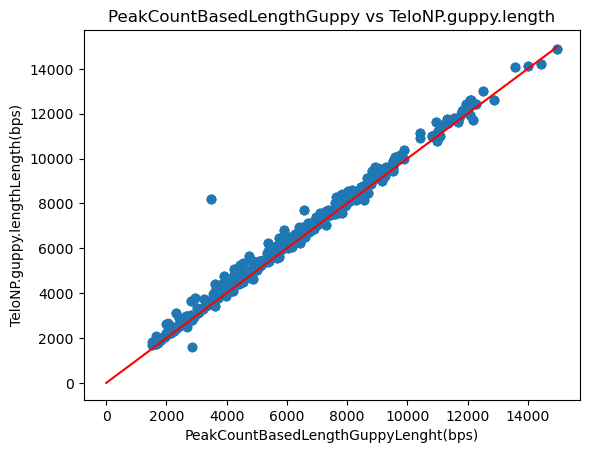

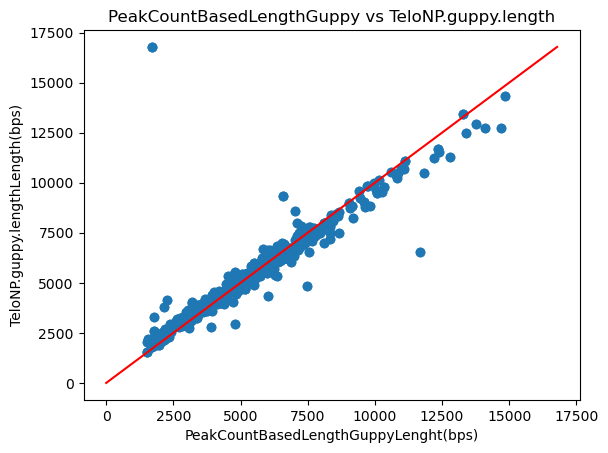

In [8]:
# raw count vs Guppy
x_values = graphingDF['PeakCountBasedLengthGuppyStrandInfo']
y_values = graphingDF['TeloNP.guppy.length']
# y_values = graphingDF['TeloNP.dorado.length']

# Plot the points
plt.scatter(x_values, y_values, alpha=0.3)
plt.plot([0,17500], [0,17500], 'r-')
plt.xlabel('Peak Counting Length(bps)')
plt.ylabel('TeloNP Guppy Length(bps)')
plt.title('Peak Counting vs TeloNP Guppy')
plt.savefig("./Figures/PeakCountingVsTeloNPGuppy.pdf")
# plt.grid(True)

correlation = graphingDF['PeakCountBasedLengthGuppyStrandInfo'].corr(graphingDF['TeloNP.guppy.length'])
print(f"pearson correlation: {correlation}")
print(f"R squared: {correlation**2}")

print(len(x_values))
print(len(y_values))

plt.show()
# pp.savefig(TelpNPVPC)
# pp.close()


GstrandDf = graphingDF[graphingDF["isGStrand"] == True]

CstrandDf = graphingDF[graphingDF["isGStrand"] == False]

# filter out reads bellow 1500 on either axis
GstrandDf = GstrandDf[(GstrandDf['PeakCountBasedLengthGuppyStrandInfo'] > 1500) & (GstrandDf['TeloNP.guppy.length'] > 1500)]
CstrandDf = CstrandDf[(CstrandDf['PeakCountBasedLengthGuppyStrandInfo'] > 1500) & (CstrandDf['TeloNP.guppy.length'] > 1500)]

gStrandR = GstrandDf['PeakCountBasedLengthGuppyStrandInfo'].corr(GstrandDf['TeloNP.guppy.length'])
gStrandR2 = gStrandR**2
print(f"GStrand pearson correlation: {gStrandR}")
print(f"GStrand R squared: {gStrandR2}")

cStrandR = CstrandDf['PeakCountBasedLengthGuppyStrandInfo'].corr(CstrandDf['TeloNP.guppy.length'])
cStrandR2 = cStrandR**2
print(f"CStrand pearson correlation: {cStrandR}")
print(f"CStrand R squared: {cStrandR2}")

graphPeaks(GstrandDf, 'PeakCountBasedLengthGuppyStrandInfo', 'TeloNP.guppy.length')
graphPeaks(CstrandDf, 'PeakCountBasedLengthGuppyStrandInfo', 'TeloNP.guppy.length')

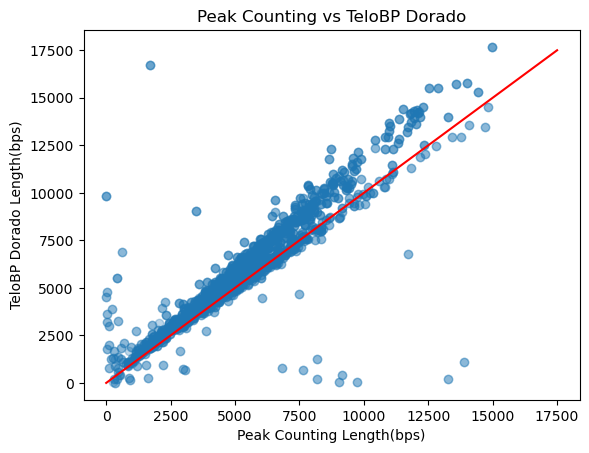

pearson correlation: 0.9038932123412572
R squared: 0.8170229393165971


In [9]:
# raw count vs Guppy
x_values = graphingDF['PeakCountBasedLengthGuppyStrandInfo']
# y_values = graphingDF['TeloNP.guppy.length']
y_values = graphingDF['TeloBP.dorado.length']

# Plot the points
plt.scatter(x_values, y_values, alpha=0.3)
plt.plot([0,17500], [0,17500], 'r-')
plt.xlabel('Peak Counting Length(bps)')
plt.ylabel('TeloBP Dorado Length(bps)')
plt.title('Peak Counting vs TeloBP Dorado')
plt.savefig("./Figures/PeakCountingVsTeloBPDorado.pdf")
# plt.grid(True)
plt.show()



correlation = graphingDF['PeakCountBasedLengthGuppyStrandInfo'].corr(graphingDF['TeloBP.dorado.length'])
print(f"pearson correlation: {correlation}")
print(f"R squared: {correlation**2}")

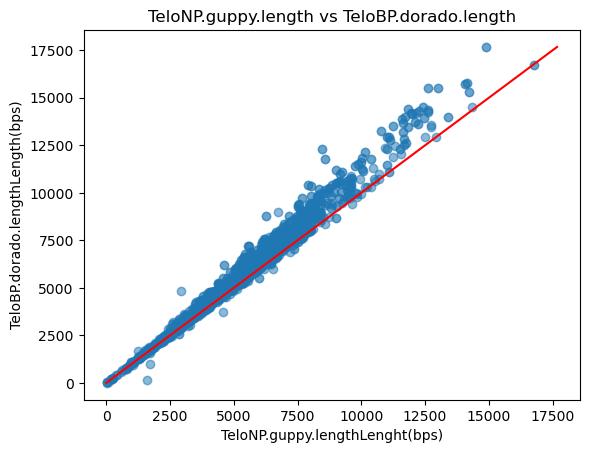

2435


In [58]:
# TeloNP Guppy vs dorado
graphPeaks(graphingDF, 'TeloNP.guppy.length', 'TeloBP.dorado.length', opacity=0.3, pdfOut="./Figures/TeloNPGuppyVsTeloBPDorado.pdf")
# get amount of reads
print(len(graphingDF))

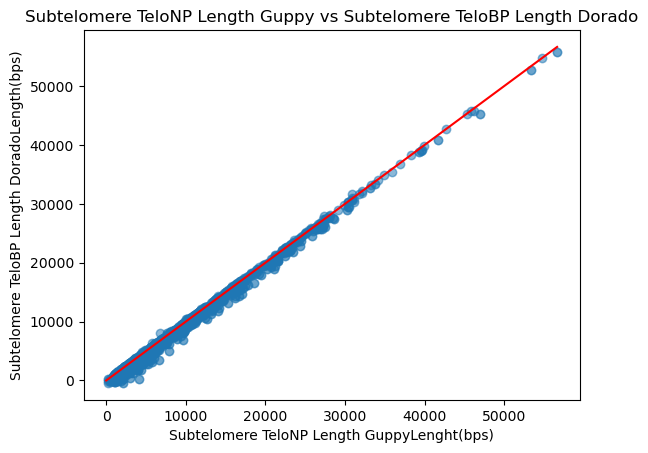

In [57]:
# Get the subtelomere lengths for each read using the peak count method

graphingDF["Subtelomere TeloNP Length Guppy"] = graphingDF["seq.ln.guppy"] - graphingDF["TeloNP.guppy.length"]
graphingDF["Subtelomere TeloBP Length Dorado"] = graphingDF["seq.ln.dorado"] - graphingDF["TeloBP.dorado.length"]

# rename TeloNp.dorado.length to TeloNP.dorado.length
# graphingDF = graphingDF.rename(columns={"TeloNp.dorado.length": "TeloNP.dorado.length"})

graphPeaks(graphingDF, 'Subtelomere TeloNP Length Guppy', 'Subtelomere TeloBP Length Dorado', opacity=0.3, pdfOut="./Figures/SubtelomereTeloNPGuppyVsTeloBPDorado.pdf") 
# graphPeaks(graphingDF, 'PeakCountBasedLengthGuppyStrandInfo', 'TeloNP.dorado.length')